In [5]:
# 1. Install the fonts
!sudo apt-get update -y
!sudo apt-get install -y ttf-mscorefonts-installer
!sudo fc-cache -f -v

# 2. Delete the Matplotlib font cache
!rm -rf ~/.cache/matplotlib

Hit:1 https://cli.github.com/packages stable InRelease
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:3 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:7 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
ttf-mscorefonts-installer is already the newest version (3.8ubuntu2).
0 upgraded, 0 newly inst

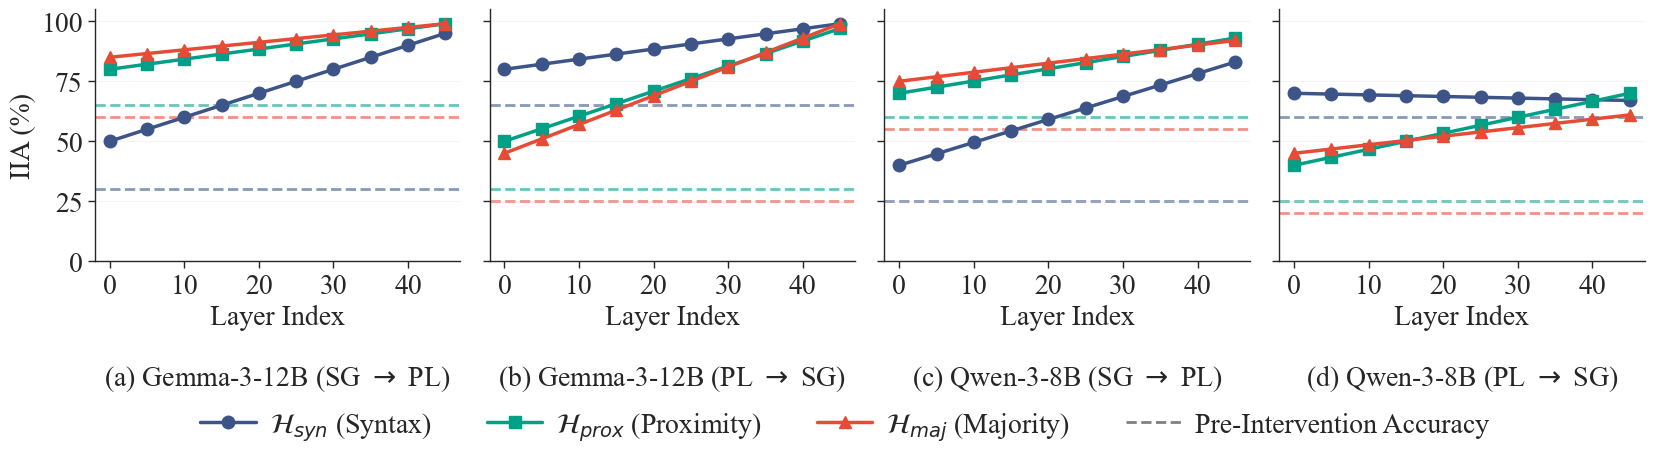

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.lines as mlines

# Apply professional ACL-style aesthetics
sns.set_theme(style="ticks", context="paper")
plt.rcParams['font.family'] = 'serif'  # Defaults safely to DejaVu Serif
plt.rcParams['font.serif'] = ['Times New Roman', 'Times', 'serif']
plt.rcParams['font.size'] = 20
plt.rcParams['axes.labelsize'] = 20
plt.rcParams['xtick.labelsize'] = 20
plt.rcParams['ytick.labelsize'] = 20
plt.rcParams['legend.fontsize'] = 20

# Define our professional color palette
COLORS = {
    'syn': '#3C5488',   # Steel Blue
    'prox': '#00A087',  # Muted Emerald
    'maj': '#E64B35'    # Brick Red
}
MARKERS = {'syn': 'o', 'prox': 's', 'maj': '^'}

# Create a 1x4 grid
fig, axes = plt.subplots(1, 4, figsize=(20, 4), sharey=True)

# ---------------------------------------------------------
# DUMMY DATA FOR DEMONSTRATION
layers = np.arange(0, 46, 5)

gemma_b2s = {'syn': np.linspace(50, 95, 10), 'prox': np.linspace(80, 99, 10), 'maj': np.linspace(85, 99, 10)}
gemma_s2b = {'syn': np.linspace(80, 99, 10), 'prox': np.linspace(50, 97, 10), 'maj': np.linspace(45, 99, 10)}
qwen_b2s = {'syn': np.linspace(40, 83, 10), 'prox': np.linspace(70, 93, 10), 'maj': np.linspace(75, 92, 10)}
qwen_s2b = {'syn': np.linspace(70, 67, 10), 'prox': np.linspace(40, 70, 10), 'maj': np.linspace(45, 61, 10)}

# DUMMY BASELINES (Pre-intervention Accuracy - % of natural counterfactual guesses)
base_gemma_b2s = {'syn': 0.30, 'prox': 0.65, 'maj': 0.60}
base_gemma_s2b = {'syn': 0.65, 'prox': 0.30, 'maj': 0.25}
base_qwen_b2s = {'syn': 0.25, 'prox': 0.60, 'maj': 0.55}
base_qwen_s2b = {'syn': 0.60, 'prox': 0.25, 'maj': 0.20}
# ---------------------------------------------------------

data_list = [gemma_b2s, gemma_s2b, qwen_b2s, qwen_s2b]
baseline_list = [base_gemma_b2s, base_gemma_s2b, base_qwen_b2s, base_qwen_s2b]

# Labels for the bottom of each plot (Removed "Patching")
sub_labels = [
    "(a) Gemma-3-12B (SG $\\rightarrow$ PL)",
    "(b) Gemma-3-12B (PL $\\rightarrow$ SG)",
    "(c) Qwen-3-8B (SG $\\rightarrow$ PL)",
    "(d) Qwen-3-8B (PL $\\rightarrow$ SG)"
]

for i, ax in enumerate(axes):
    data = data_list[i]
    bases = baseline_list[i]

    # Plot the three hypotheses (IIA)
    ax.plot(layers, data['syn'], marker=MARKERS['syn'], color=COLORS['syn'],
            linewidth=2.5, markersize=9)
    ax.plot(layers, data['prox'], marker=MARKERS['prox'], color=COLORS['prox'],
            linewidth=2.5, markersize=9)
    ax.plot(layers, data['maj'], marker=MARKERS['maj'], color=COLORS['maj'],
            linewidth=2.5, markersize=9)

    # Plot the three dataset-specific Pre-intervention Accuracies
    ax.axhline(y=bases['syn'] * 100, color=COLORS['syn'], linestyle='--', linewidth=2, alpha=0.6, zorder=0)
    ax.axhline(y=bases['prox'] * 100, color=COLORS['prox'], linestyle='--', linewidth=2, alpha=0.6, zorder=0)
    ax.axhline(y=bases['maj'] * 100, color=COLORS['maj'], linestyle='--', linewidth=2, alpha=0.6, zorder=0)

    # Setup axes
    ax.set_ylim(0, 105)
    ax.set_xlim(-2, 47)
    ax.set_xticks([0, 10, 20, 30, 40])
    ax.set_xlabel(f"Layer Index\n\n{sub_labels[i]}")

    if i == 0:
        ax.set_ylabel("IIA (%)")
        ax.set_yticks([0, 25, 50, 75, 100])

    ax.yaxis.grid(True, linestyle='-', alpha=0.2)

# Custom Legend with corrected terminology
legend_elements = [
    mlines.Line2D([0], [0], color=COLORS['syn'], marker=MARKERS['syn'], linewidth=2.5, markersize=9, label=r'$\mathcal{H}_{syn}$ (Syntax)'),
    mlines.Line2D([0], [0], color=COLORS['prox'], marker=MARKERS['prox'], linewidth=2.5, markersize=9, label=r'$\mathcal{H}_{prox}$ (Proximity)'),
    mlines.Line2D([0], [0], color=COLORS['maj'], marker=MARKERS['maj'], linewidth=2.5, markersize=9, label=r'$\mathcal{H}_{maj}$ (Majority)'),
    mlines.Line2D([0], [0], color='grey', linestyle='--', linewidth=2, label='Pre-Intervention Accuracy')
]

fig.legend(handles=legend_elements, loc='upper center', ncol=4,
           bbox_to_anchor=(0.5, -0.06), frameon=False, handletextpad=0.5, columnspacing=2)

sns.despine()
plt.subplots_adjust(wspace=0.08, bottom=0.25)
plt.savefig("DAS_Results_Gemma-Qwen.pdf", dpi=500, bbox_inches='tight')
plt.show()